# 🔧 Notebook 03 — Feature Engineering
### IEEE-CIS Fraud Detection · Educational Notebook

---

## 🎯 What this notebook is about

After cleaning and EDA, we now **engineer the features** that will actually power our model.
Raw data alone is rarely enough — the real lift comes from domain-specific transformations.

In this notebook we build:

| # | Feature Group | Why it matters |
|---|---------------|----------------|
| 1 | **UID Reconstruction** | No user ID exists — we engineer one from card + address + D1 |
| 2 | **Aggregation Features** | User behavior baseline: how much does THIS transaction deviate? |
| 3 | **Email Match** | Same buyer/recipient email = 4x higher fraud rate |
| 4 | **Frequency Encoding** | Replace raw IDs with how often they appear (generalization) |
| 5 | **Time Encoding** | Sin/cos transform so hour 23 and hour 0 are treated as neighbors |

---

## 📚 Research basis

| Source | What we take from it |
|--------|----------------------|
| Kaggle 1st & 2nd Place Writeups | UID formula (card1 + addr1 + D1n), frequency encoding, post-processing tricks |
| Chris Deotte (Kaggle Grandmaster) | D1 secret: D1 = days since first card transaction → D1n = card issue date |
| *"Robust Fraud Detection"* (2025) | Feature engineering drives more lift than model switching |


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('darkgrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Load the dataset produced by Notebook 02
# (merged, downcasted, NaN-indicators already added, PCA applied to V-features)
print('Loading dataset...')
train = pd.read_parquet('../data/train_merged.parquet')

print(f'Loaded: {train.shape[0]:,} rows x {train.shape[1]} columns')
print(f'Fraud rate: {train["isFraud"].mean():.2%}')
print(f'Memory usage: {train.memory_usage().sum() / 1024**2:.1f} MB')

Loading dataset...
Loaded: 590,540 rows x 434 columns
Fraud rate: 3.50%
Memory usage: 1044.7 MB


---
## 1️⃣ UID Reconstruction
### *"There is no user ID — so we build one."*

### Why we do this

The dataset has no stable user identifier. Each row is a transaction — but fraudsters are **accounts**, not transactions.
To detect behavioral anomalies ("this user never spends this much"), we need to group transactions by user.

**The D1 secret (Chris Deotte, Kaggle Grandmaster):**
> D1 = "days since the card's first transaction"
> So: `TransactionDay - D1 = the card's issue date` = a time-invariant identifier

Combined with `card1` and `addr1`, this gives us a pseudo-UID that tracks the same physical person across months.

**Critical warning:** We NEVER feed the UID directly into the model.
- 68% of clients in the test set are completely new
- If the model memorizes UIDs, it fails on unseen clients
- UIDs are only used to compute group statistics → then dropped


In [13]:
# ── Step 1: Reconstruct the card issue date ────────────────────────────────────
#
# TransactionDT is seconds since a reference point (not a real timestamp).
# Convert to days first.
#
# D1 = "days since this card was first used"
# D1n = TransactionDay - D1 = the day the card was 'born' (time-invariant)

train['TransactionDay'] = (train['TransactionDT'] // 86400).astype(np.int16)

# D1 might have NaNs — fill with 0 so the UID is still valid (just less precise)
train['D1_filled'] = train['D1'].fillna(0).astype(np.int16)
train['D1n'] = (train['TransactionDay'] - train['D1_filled']).astype(np.int16)

print(f'TransactionDay range: {train["TransactionDay"].min()} - {train["TransactionDay"].max()}')
print(f'D1n range: {train["D1n"].min()} - {train["D1n"].max()}')
print(f'D1 NaN rate: {train["D1"].isnull().mean():.1%}')

TransactionDay range: 1 - 182
D1n range: -633 - 182
D1 NaN rate: 0.2%


In [14]:
# ── Step 2: Build the UID ──────────────────────────────────────────────────────
#
# card1 = card identifier (anonymized)
# addr1 = billing address (anonymized)
# D1n   = card issue date (derived above)
#
# Together: same card + same billing address + same issue date = same person

train['UID'] = (train['card1'].astype(str) + '_' +
                train['addr1'].fillna(-1).astype(int).astype(str) + '_' +
                train['D1n'].astype(str) + '_' +
                train['P_emaildomain'].fillna('unknown').astype(str))

n_unique_uids  = train['UID'].nunique()
n_transactions = len(train)
avg_per_uid    = n_transactions / n_unique_uids

print(f'Unique UIDs:             {n_unique_uids:,}')
print(f'Total transactions:      {n_transactions:,}')
print(f'Avg transactions / UID:  {avg_per_uid:.1f}')
print(f'Example UIDs:')
print(train['UID'].head(5).tolist())

Unique UIDs:             273,693
Total transactions:      590,540
Avg transactions / UID:  2.2
Example UIDs:
['13926_315_-13_unknown', '2755_325_1_gmail.com', '4663_330_1_outlook.com', '18132_476_-111_yahoo.com', '4497_420_1_gmail.com']


---
## 2️⃣ Aggregation Features
### *"How much does THIS transaction deviate from the user's normal behavior?"*

### Why we do this

The raw transaction amount alone is not very informative.
A \$500 transaction might be completely normal for one user, but highly suspicious for another.

By computing **per-UID statistics**, we transform absolute values into **relative signals**:
- `uid_amt_mean`: What does this user usually spend?
- `uid_amt_std`:  How variable is their spending?
- `uid_amt_zscore`: Is THIS transaction unusually high/low vs. their own baseline?
- `uid_count`: How many transactions has this card made? (new cards are more suspicious)

**Key insight from Kaggle winners:**
> "The amt_zscore feature ended up in the Top 20 most important features.
>  Feature engineering drives more lift than switching models."


In [15]:
# ── Per-UID transaction amount statistics ──────────────────────────────────────

print('Computing UID aggregation features...')

# Mean and standard deviation of transaction amount per UID
train['uid_amt_mean'] = train.groupby('UID')['TransactionAmt'].transform('mean').astype(np.float32)
train['uid_amt_std']  = train.groupby('UID')['TransactionAmt'].transform('std').astype(np.float32)

# Z-score: how many standard deviations above/below the user's mean is this transaction?
# If std == 0 (user only has 1 transaction), replace with 1 to avoid division by zero
train['uid_amt_zscore'] = (
    (train['TransactionAmt'] - train['uid_amt_mean'])
    / train['uid_amt_std'].replace(0, 1)
).astype(np.float32)

# Transaction count per UID — new cards (low count) are more suspicious
train['uid_count'] = train.groupby('UID')['TransactionAmt'].transform('count').astype(np.int16)

# Transaction frequency: how many transactions per day for this UID?
train['uid_freq_per_day'] = (train.groupby(['UID', 'TransactionDay'])['TransactionAmt']
                              .transform('count')
                              .astype(np.int16))

print(f'New features created: uid_amt_mean, uid_amt_std, uid_amt_zscore, uid_count, uid_freq_per_day')
print(f'\nZ-score stats:')
print(train['uid_amt_zscore'].describe().round(2))

Computing UID aggregation features...
New features created: uid_amt_mean, uid_amt_std, uid_amt_zscore, uid_count, uid_freq_per_day

Z-score stats:
count    413310.00
mean         -0.00
std           0.83
min          -5.47
25%          -0.66
50%           0.00
75%           0.62
max           8.26
Name: uid_amt_zscore, dtype: float64


Fraud rate by Z-score bin:
            fraud_rate  n_transactions  fraud_rate_pct
zscore_bin                                            
<-2           0.034801            1408            3.48
-2 to -1      0.037706           32356            3.77
-1 to 0       0.038566          216694            3.86
0 to 1        0.039749          114467            3.97
1 to 2        0.040621           40915            4.06
2 to 3        0.039231            6398            3.92
>3            0.044776            1072            4.48


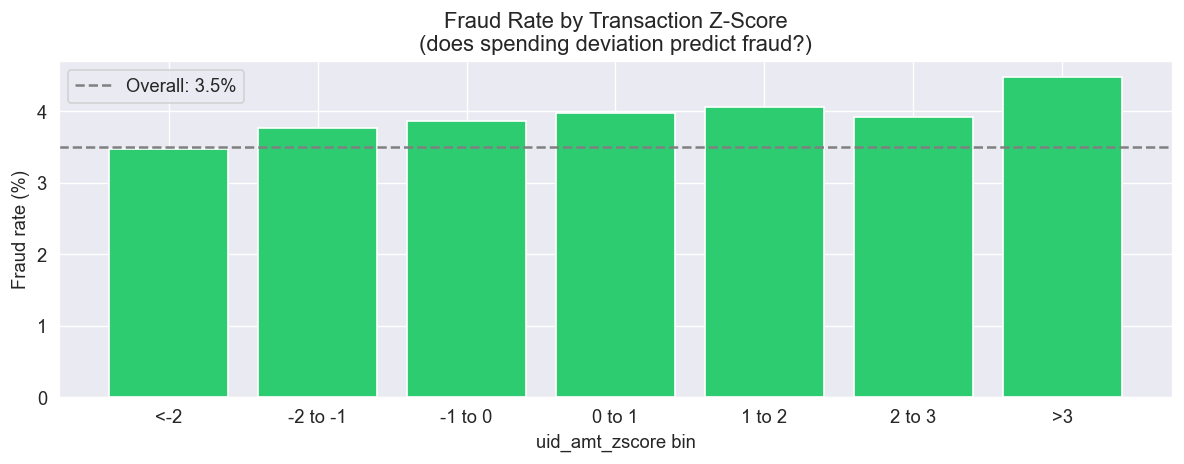

Saved: reports/zscore_fraud_rate.png


In [16]:
# ── Validate: does uid_amt_zscore actually correlate with fraud? ───────────────

# Bin the z-score and check fraud rate per bin
bins = [-np.inf, -2, -1, 0, 1, 2, 3, np.inf]
labels = ['<-2', '-2 to -1', '-1 to 0', '0 to 1', '1 to 2', '2 to 3', '>3']

train['zscore_bin'] = pd.cut(train['uid_amt_zscore'], bins=bins, labels=labels)

zscore_fraud = (train.groupby('zscore_bin', observed=True)['isFraud']
                .agg(['mean', 'count'])
                .rename(columns={'mean': 'fraud_rate', 'count': 'n_transactions'}))
zscore_fraud['fraud_rate_pct'] = (zscore_fraud['fraud_rate'] * 100).round(2)

print('Fraud rate by Z-score bin:')
print(zscore_fraud.to_string())

# Clean up the helper column
train = train.drop(columns=['zscore_bin'])

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(zscore_fraud.index, zscore_fraud['fraud_rate_pct'],
              color=['#2ecc71' if v < 5 else '#e74c3c' for v in zscore_fraud['fraud_rate_pct']],
              edgecolor='white')
ax.axhline(train['isFraud'].mean() * 100, color='gray', linestyle='--', label=f'Overall: {train["isFraud"].mean():.1%}')
ax.set_xlabel('uid_amt_zscore bin')
ax.set_ylabel('Fraud rate (%)')
ax.set_title('Fraud Rate by Transaction Z-Score\n(does spending deviation predict fraud?)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/zscore_fraud_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: reports/zscore_fraud_rate.png')

---
## 3️⃣ Email Domain Match
### *"When buyer and recipient share an email domain — it's 4x more likely to be fraud"*

### Why we do this

From Notebook 02 we already know:
- Overall fraud rate: **3.5%**
- When P_emaildomain == R_emaildomain: **9.7%** (fraudsters often use the same throwaway email)

This is a one-line feature, but it carries strong signal.


In [17]:
# ── Email domain match feature ─────────────────────────────────────────────────

if 'P_emaildomain' in train.columns and 'R_emaildomain' in train.columns:
    train['email_match'] = (
        (train['P_emaildomain'] == train['R_emaildomain']).astype(np.int8)
    )

    match_fraud_rate    = train[train['email_match'] == 1]['isFraud'].mean()
    mismatch_fraud_rate = train[train['email_match'] == 0]['isFraud'].mean()
    overall_fraud_rate  = train['isFraud'].mean()

    print(f'Email Domain Match Analysis:')
    print(f'  Overall fraud rate:              {overall_fraud_rate:.2%}')
    print(f'  Fraud rate when emails MATCH:    {match_fraud_rate:.2%}   <- P_email == R_email')
    print(f'  Fraud rate when emails MISMATCH: {mismatch_fraud_rate:.2%}   <- P_email != R_email')
    mult = match_fraud_rate / overall_fraud_rate if overall_fraud_rate > 0 else 0
    print(f'  -> Email match is {mult:.1f}x more likely to be fraud than average')
else:
    print('P_emaildomain / R_emaildomain columns not found -- check column names.')

Email Domain Match Analysis:
  Overall fraud rate:              3.50%
  Fraud rate when emails MATCH:    9.65%   <- P_email == R_email
  Fraud rate when emails MISMATCH: 2.21%   <- P_email != R_email
  -> Email match is 2.8x more likely to be fraud than average


---
## 4️⃣ Frequency Encoding
### *"How often does this card appear? Rare = more suspicious"*

### Why we do this

Raw categorical IDs like `card1 = 12345` mean nothing to the model.
Frequency encoding replaces each value with **how often it appears in the training data**.

The model then learns:
> "A card that appears only once is more suspicious than one with 500 transactions."

This also solves the **unseen categories problem**: if a card appears in the test set but not in training,
it gets frequency = 0 — which is actually informative (brand new card = higher risk).

**Important:** Compute frequency on the FULL training set, not just a sample.
Frequencies computed on a subset would be systematically underestimated.


In [18]:
# ── Frequency encoding for high-cardinality categorical columns ────────────────

freq_encode_cols = ['card1', 'card2', 'card3', 'card5', 'addr1', 'addr2',
                    'P_emaildomain', 'R_emaildomain']

# Only encode columns that actually exist in the dataset
freq_encode_cols = [c for c in freq_encode_cols if c in train.columns]

print('Applying frequency encoding...')
for col in freq_encode_cols:
    freq_map = train[col].value_counts()
    new_col  = f'{col}_freq'
    train[new_col] = train[col].map(freq_map).fillna(0).astype(np.int32)
    print(f'  {col:20s} -> {new_col:25s}  (unique values: {freq_map.shape[0]:,})')

print(f'\nFrequency encoding complete. New columns: {[c + "_freq" for c in freq_encode_cols]}')

Applying frequency encoding...
  card1                -> card1_freq                 (unique values: 13,553)
  card2                -> card2_freq                 (unique values: 500)
  card3                -> card3_freq                 (unique values: 114)
  card5                -> card5_freq                 (unique values: 119)
  addr1                -> addr1_freq                 (unique values: 332)
  addr2                -> addr2_freq                 (unique values: 74)
  P_emaildomain        -> P_emaildomain_freq         (unique values: 59)
  R_emaildomain        -> R_emaildomain_freq         (unique values: 60)

Frequency encoding complete. New columns: ['card1_freq', 'card2_freq', 'card3_freq', 'card5_freq', 'addr1_freq', 'addr2_freq', 'P_emaildomain_freq', 'R_emaildomain_freq']


Fraud rate by card1 frequency:
                fraud_rate  n_transactions  fraud_rate_pct
card1_freq_bin                                            
1                 0.042393            3444            4.24
2-5               0.029276           13014            2.93
6-20              0.025519           36287            2.55
21-100            0.027065           77812            2.71
101-500           0.038465          108385            3.85
500+              0.036789          351598            3.68


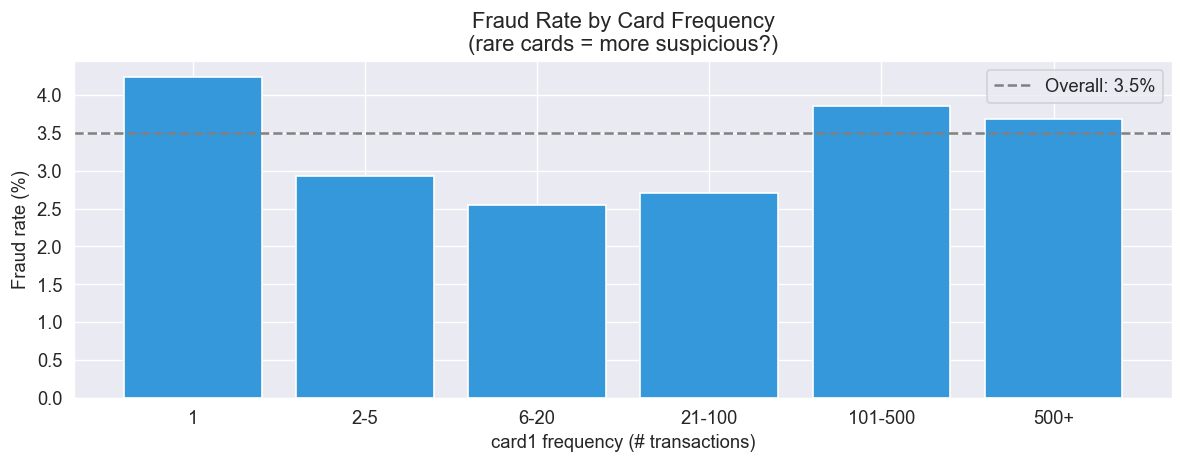

Saved: reports/card_freq_fraud_rate.png


In [19]:
# ── Validate: does card frequency correlate with fraud? ────────────────────────

# Low-frequency cards should have higher fraud rates
bins = [0, 1, 5, 20, 100, 500, np.inf]
labels = ['1', '2-5', '6-20', '21-100', '101-500', '500+']

train['card1_freq_bin'] = pd.cut(train['card1_freq'], bins=bins, labels=labels)

freq_fraud = (train.groupby('card1_freq_bin', observed=True)['isFraud']
              .agg(['mean', 'count'])
              .rename(columns={'mean': 'fraud_rate', 'count': 'n_transactions'}))
freq_fraud['fraud_rate_pct'] = (freq_fraud['fraud_rate'] * 100).round(2)

print('Fraud rate by card1 frequency:')
print(freq_fraud.to_string())

train = train.drop(columns=['card1_freq_bin'])

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(freq_fraud.index, freq_fraud['fraud_rate_pct'],
       color='#3498db', edgecolor='white')
ax.axhline(train['isFraud'].mean() * 100, color='gray', linestyle='--',
           label=f'Overall: {train["isFraud"].mean():.1%}')
ax.set_xlabel('card1 frequency (# transactions)')
ax.set_ylabel('Fraud rate (%)')
ax.set_title('Fraud Rate by Card Frequency\n(rare cards = more suspicious?)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/card_freq_fraud_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: reports/card_freq_fraud_rate.png')

---
## 5️⃣ Time Encoding
### *"Hour 23 and hour 0 are neighbors — but 23 > 0 breaks that"*

### Why we do this

`TransactionDT` is a raw integer (seconds since reference point).
If we extract the hour (0-23) directly, the model sees hour 23 and hour 0 as far apart.
But in reality, 11pm and midnight are adjacent.

**Sin/cos encoding** solves this by mapping the hour to a circle:
- `hour_sin = sin(2π × hour / 24)`
- `hour_cos = cos(2π × hour / 24)`

Now hour 23 and hour 0 are numerically close, as they should be.
Same principle applies to day of week.


Time features created: hour, dayofweek, hour_sin, hour_cos, dayofweek_sin, dayofweek_cos


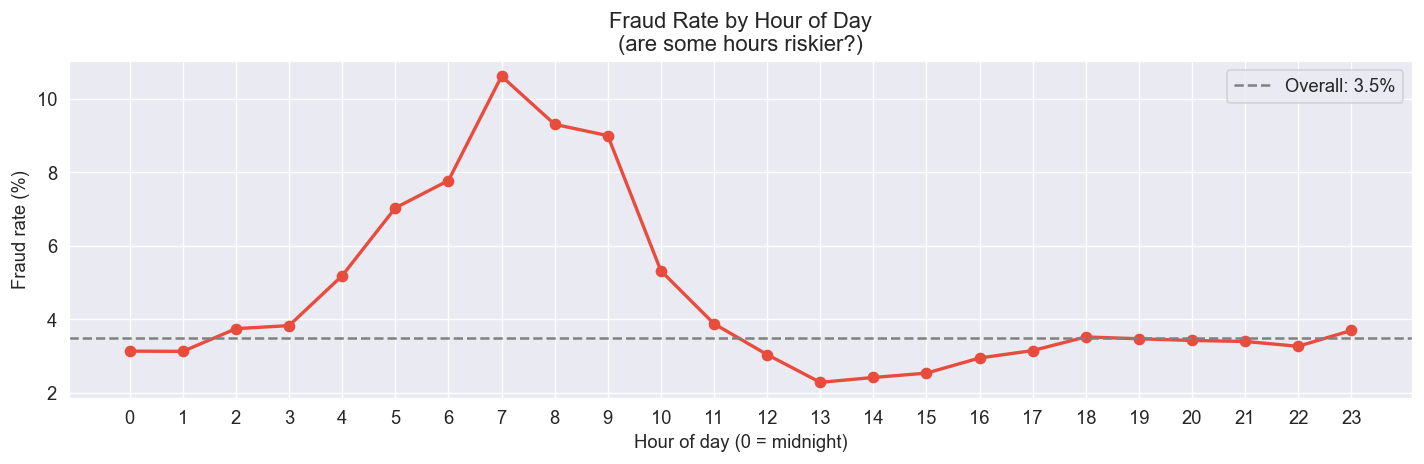

Saved: reports/hour_fraud_rate.png


In [20]:
# ── Time encoding: sin/cos for hour of day and day of week ────────────────────

# Extract hour (0-23) and day of week (0-6) from TransactionDT
# TransactionDT is seconds since reference point
train['hour']       = ((train['TransactionDT'] // 3600) % 24).astype(np.int8)
train['dayofweek']  = ((train['TransactionDT'] // 86400) % 7).astype(np.int8)

# Sin/cos encoding — projects cyclical features onto a circle
train['hour_sin']      = np.sin(2 * np.pi * train['hour'] / 24).astype(np.float32)
train['hour_cos']      = np.cos(2 * np.pi * train['hour'] / 24).astype(np.float32)
train['dayofweek_sin'] = np.sin(2 * np.pi * train['dayofweek'] / 7).astype(np.float32)
train['dayofweek_cos'] = np.cos(2 * np.pi * train['dayofweek'] / 7).astype(np.float32)

print('Time features created: hour, dayofweek, hour_sin, hour_cos, dayofweek_sin, dayofweek_cos')

# Quick sanity check: fraud rate by hour
hour_fraud = train.groupby('hour')['isFraud'].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hour_fraud.index, hour_fraud.values * 100, marker='o', color='#e74c3c', linewidth=2)
ax.axhline(train['isFraud'].mean() * 100, color='gray', linestyle='--',
           label=f'Overall: {train["isFraud"].mean():.1%}')
ax.set_xlabel('Hour of day (0 = midnight)')
ax.set_ylabel('Fraud rate (%)')
ax.set_title('Fraud Rate by Hour of Day\n(are some hours riskier?)')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.savefig('../reports/hour_fraud_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: reports/hour_fraud_rate.png')

---
## 6️⃣ Cleanup & Save

Before saving, we:
1. **Drop the UID column** — it was only needed to compute aggregations. Never feed raw IDs to the model.
2. **Drop helper columns** we no longer need.
3. **Save to Parquet** for Notebook 04 (model training).


In [21]:
# ── Drop UID and helper columns before saving ─────────────────────────────────
#
# CRITICAL: drop UID -- model must not memorize card IDs
# 68% of clients in test set are unseen

cols_to_drop = ['UID', 'D1_filled', 'TransactionDay']
cols_to_drop = [c for c in cols_to_drop if c in train.columns]

train = train.drop(columns=cols_to_drop)
print(f'Dropped columns: {cols_to_drop}')

# Final dataset overview
print(f'\nFinal dataset shape: {train.shape}')
print(f'Memory usage: {train.memory_usage().sum() / 1024**2:.1f} MB')
print(f'Fraud rate: {train["isFraud"].mean():.2%}')

# List all new features we created
new_features = [
    'uid_amt_mean', 'uid_amt_std', 'uid_amt_zscore', 'uid_count', 'uid_freq_per_day',
    'email_match',
    'card1_freq', 'card2_freq', 'card3_freq', 'card5_freq',
    'addr1_freq', 'addr2_freq', 'P_emaildomain_freq', 'R_emaildomain_freq',
    'hour', 'dayofweek', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos',
    'D1n'
]
existing = [f for f in new_features if f in train.columns]
print(f'\nNew features in dataset ({len(existing)} total):')
for f in existing:
    print(f'  {f}')

Dropped columns: ['UID', 'D1_filled', 'TransactionDay']

Final dataset shape: (590540, 455)
Memory usage: 1083.6 MB
Fraud rate: 3.50%

New features in dataset (21 total):
  uid_amt_mean
  uid_amt_std
  uid_amt_zscore
  uid_count
  uid_freq_per_day
  email_match
  card1_freq
  card2_freq
  card3_freq
  card5_freq
  addr1_freq
  addr2_freq
  P_emaildomain_freq
  R_emaildomain_freq
  hour
  dayofweek
  hour_sin
  hour_cos
  dayofweek_sin
  dayofweek_cos
  D1n


In [22]:
# ── Save engineered dataset for Notebook 04 ───────────────────────────────────

output_path = '../data/train_engineered.parquet'
train.to_parquet(output_path, index=False)
print(f'Saved: {output_path}')
print(f'Shape: {train.shape}')
print(f'\nReady for Notebook 04: Model Training & Benchmarking')

Saved: ../data/train_engineered.parquet
Shape: (590540, 455)

Ready for Notebook 04: Model Training & Benchmarking


---
## 💡 Summary — What we built

| Feature | How it works | Why it matters |
|---------|-------------|----------------|
| `uid_amt_zscore` | Z-score of transaction vs. user's own mean | Detects anomalous spending regardless of absolute amount |
| `uid_count` | How many transactions has this card made? | New cards = higher risk |
| `uid_freq_per_day` | Transactions per day for this UID | Burst activity = fraud signal |
| `email_match` | P_emaildomain == R_emaildomain | 9.7% vs 2.2% fraud rate |
| `card1_freq` | How often does this card appear? | Rare cards = more suspicious |
| `hour_sin/cos` | Cyclical hour encoding | 23:00 and 00:00 are neighbors |

**Key lesson:**
> *"Feature engineering drives more lift than switching from LightGBM to a neural network.
>  A simple model with rich features beats a complex model with raw data every time."*

**Next:** Notebook 04 — Model Training & Benchmarking
